<a href="https://colab.research.google.com/github/younus1082/Air_Mouse_ESP32/blob/main/Neural-Networks-Lab%20/Lab%20Assignment%203/Lab%20Assignment%203%20%7C%20Younus_1082_(8A2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Imports and Device Setup

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import time

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


Task 1: Data Exploration and Preprocessing


--- Task 1: Data Exploration and Preprocessing ---
Displaying 5 random images with labels:


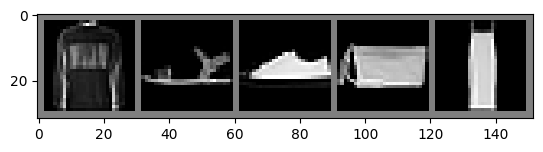

Labels: Pullover | Sandal | Sneaker | Bag | Dress
Shape of one batch of images: torch.Size([128, 1, 28, 28])
Meaning of dimensions: [Batch Size (128), Channels (1 for grayscale), Height (28 pixels), Width (28 pixels)]


In [ ]:
print("\n--- Task 1: Data Exploration and Preprocessing ---")

# 1 & 2: Load and normalize dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

classes = trainset.classes

# 3: Display 5 random images
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

print("Displaying 5 random images with labels:")
imshow(torchvision.utils.make_grid(images[:5]))
print('Labels:', ' | '.join(f'{classes[labels[j]]}' for j in range(5)))

# 4: Print shape
print(f"Shape of one batch of images: {images.shape}")
print("Meaning of dimensions: [Batch Size (128), Channels (1 for grayscale), Height (28 pixels), Width (28 pixels)]")

Helper Functions for Training and Plotting

In [ ]:
def train_evaluate_model(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    start_time = time.time()

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / total

        # Validation Phase
        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_loss = val_loss / len(test_loader.dataset)
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    training_time = time.time() - start_time

    # Count Parameters
    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return train_losses, val_losses, train_accs, val_accs, training_time, param_count

def plot_curves(train_losses, val_losses, title):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(6, 4))
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

Task 2: Architecture Design Experiment


--- Task 2: Architecture Design Experiment ---

Training Model A...


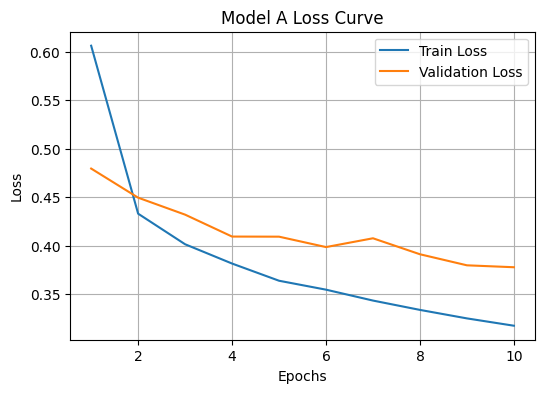

Model A Final Test Accuracy: 0.8660 | Parameters: 25450

Training Model B...


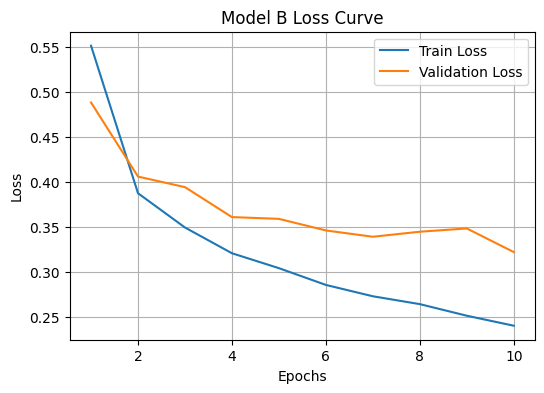

Model B Final Test Accuracy: 0.8879 | Parameters: 109386

Training Model C...


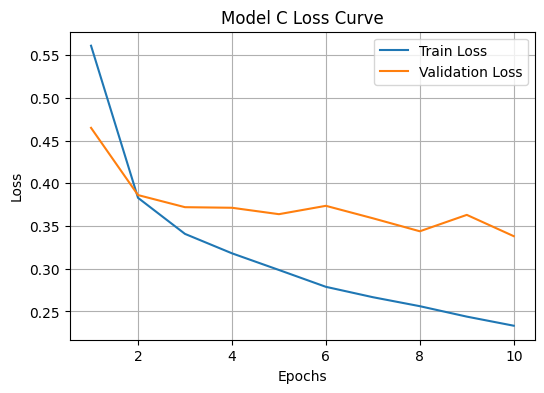

Model C Final Test Accuracy: 0.8838 | Parameters: 242762

Best Performing Model: Model B


In [ ]:
print("\n--- Task 2: Architecture Design Experiment ---")

class ModelA(nn.Module): # 784 -> 32 -> 10
    def __init__(self):
        super(ModelA, self).__init__()
        self.fc1 = nn.Linear(28*28, 32)
        self.fc2 = nn.Linear(32, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

class ModelB(nn.Module): # 784 -> 128 -> 64 -> 10
    def __init__(self):
        super(ModelB, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

class ModelC(nn.Module): # 784 -> 256 -> 128 -> 64 -> 10
    def __init__(self):
        super(ModelC, self).__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        return self.fc4(x)

models = {'Model A': ModelA(), 'Model B': ModelB(), 'Model C': ModelC()}
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_l, val_l, train_a, val_a, t_time, p_count = train_evaluate_model(model, optimizer, epochs=10)
    results[name] = {'val_acc': val_a[-1], 'params': p_count, 'time': t_time}
    plot_curves(train_l, val_l, f'{name} Loss Curve')
    print(f"{name} Final Test Accuracy: {val_a[-1]:.4f} | Parameters: {p_count}")

best_model_name = max(results, key=lambda k: results[k]['val_acc'])
print(f"\nBest Performing Model: {best_model_name}")

Task 3: Underfitting vs Overfitting Analysis


--- Task 3: Underfitting vs Overfitting Analysis ---

Training Model Small (Underfit)...


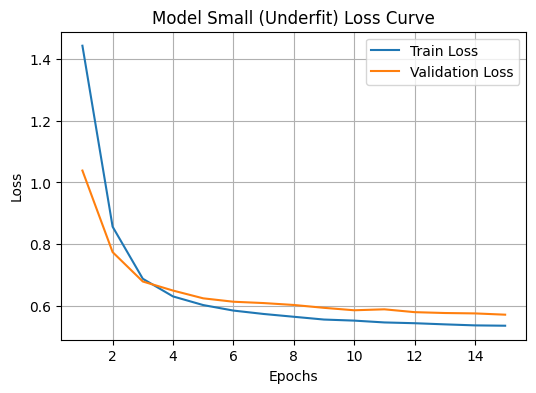

Final Train Acc: 0.8003 | Final Test Acc: 0.7884

Training Model Large (Overfit)...


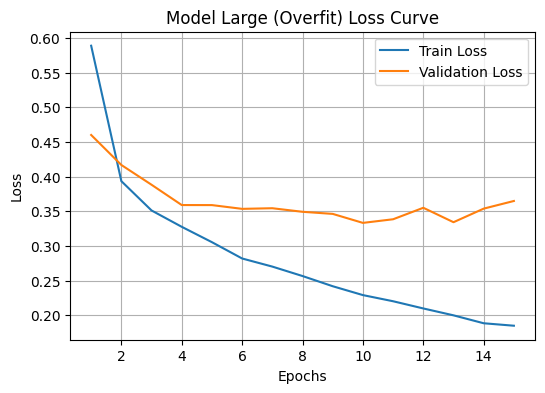

Final Train Acc: 0.9305 | Final Test Acc: 0.8877


In [ ]:
print("\n--- Task 3: Underfitting vs Overfitting Analysis ---")

class ModelSmall(nn.Module): # 784 -> 4 -> 10
    def __init__(self):
        super(ModelSmall, self).__init__()
        self.fc1 = nn.Linear(28*28, 4)
        self.fc2 = nn.Linear(4, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

class ModelLarge(nn.Module): # 784 -> 1024 -> 512 -> 256 -> 128 -> 64 -> 10
    def __init__(self):
        super(ModelLarge, self).__init__()
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 64)
        self.fc6 = nn.Linear(64, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        x = torch.relu(self.fc5(x))
        return self.fc6(x)

extreme_models = {'Model Small (Underfit)': ModelSmall(), 'Model Large (Overfit)': ModelLarge()}

for name, model in extreme_models.items():
    print(f"\nTraining {name}...")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_l, val_l, train_a, val_a, t_time, p_count = train_evaluate_model(model, optimizer, epochs=15)
    plot_curves(train_l, val_l, f'{name} Loss Curve')
    print(f"Final Train Acc: {train_a[-1]:.4f} | Final Test Acc: {val_a[-1]:.4f}")

Task 4: Batch Normalization Study


--- Task 4: Batch Normalization Study ---
Training Best Model with BatchNorm...


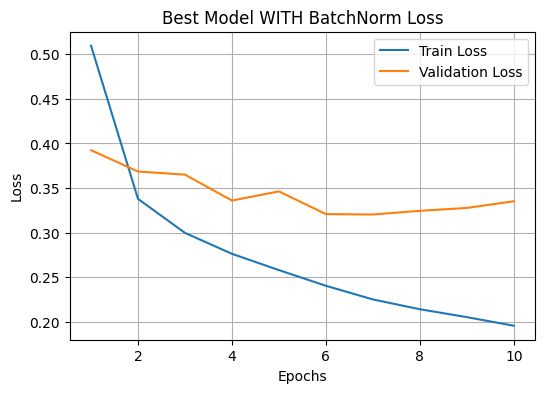

Final Test Acc with BN: 0.8834 | Parameters with BN: 109770


In [ ]:
print("\n--- Task 4: Batch Normalization Study ---")

class ModelB_BN(nn.Module):
    def __init__(self):
        super(ModelB_BN, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 10)
    def forward(self, x):
        x = torch.flatten(x, 1)
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

model_bn = ModelB_BN().to(device)
optimizer_bn = optim.Adam(model_bn.parameters(), lr=0.001)

print("Training Best Model with BatchNorm...")
bn_train_l, bn_val_l, bn_train_a, bn_val_a, bn_time, bn_params = train_evaluate_model(model_bn, optimizer_bn, epochs=10)
plot_curves(bn_train_l, bn_val_l, 'Best Model WITH BatchNorm Loss')
print(f"Final Test Acc with BN: {bn_val_a[-1]:.4f} | Parameters with BN: {bn_params}")

Task 5: Error Analysis


--- Task 5: Error Analysis ---


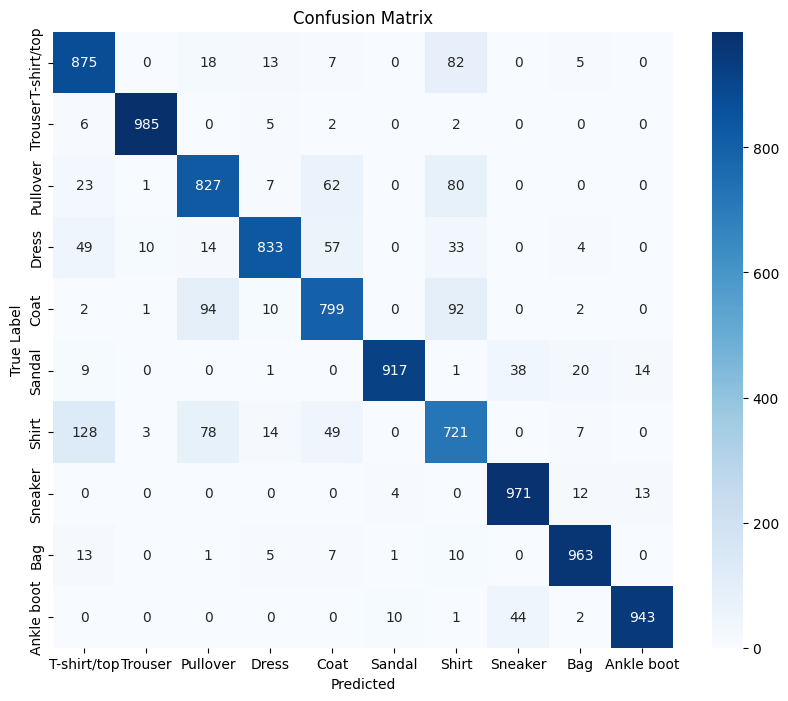

Displaying 10 Misclassified Images:


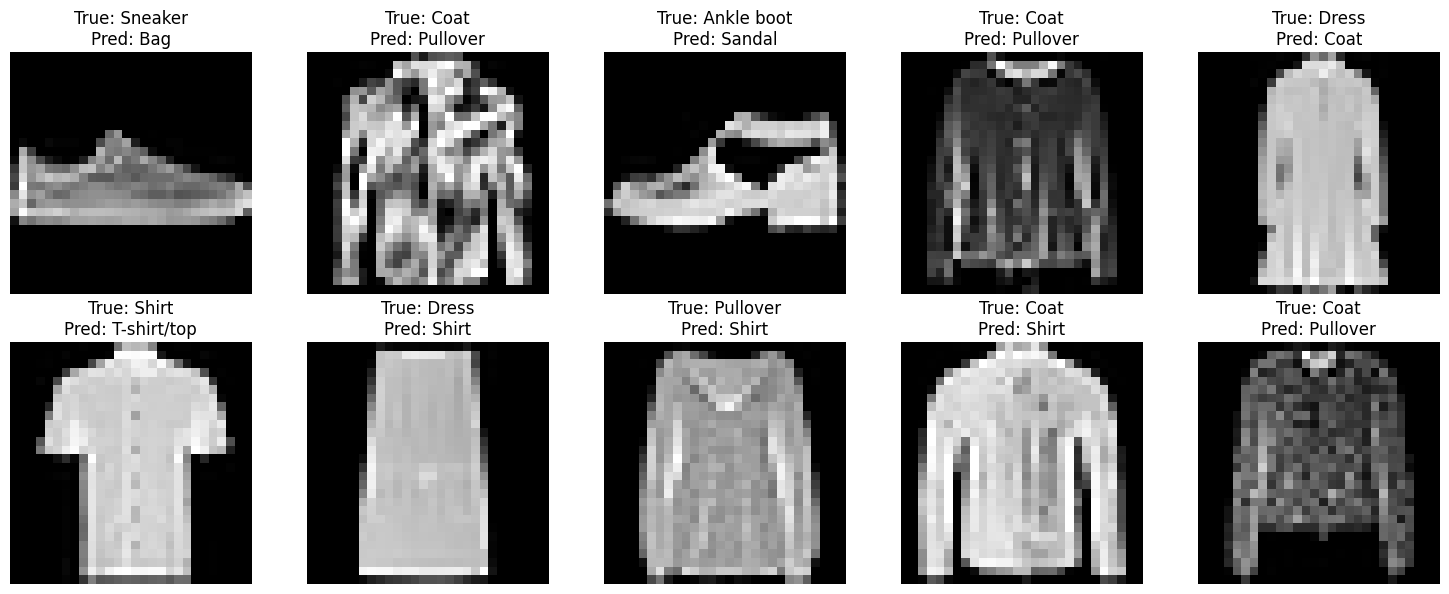

In [ ]:
print("\n--- Task 5: Error Analysis ---")
model_bn.eval()
all_preds = []
all_labels = []
misclassified_imgs = []
misclassified_preds = []
misclassified_true = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_bn(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Collect misclassified examples
        mismatches = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in mismatches:
            if len(misclassified_imgs) < 10:
                misclassified_imgs.append(inputs[idx].cpu())
                misclassified_preds.append(preds[idx].item())
                misclassified_true.append(labels[idx].item())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True Label")
plt.show()

# Display Misclassified
print("Displaying 10 Misclassified Images:")
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    if i < len(misclassified_imgs):
        img = misclassified_imgs[i] / 2 + 0.5
        ax.imshow(np.transpose(img.numpy(), (1, 2, 0)), cmap='gray')
        ax.set_title(f"True: {classes[misclassified_true[i]]}\nPred: {classes[misclassified_preds[i]]}")
        ax.axis('off')
plt.tight_layout()
plt.show()

Task 6: Model Efficiency Comparison

In [ ]:
print("\n--- Task 6: Model Efficiency Comparison ---")
print(f"{'Model':<15} | {'Parameters':<12} | {'Accuracy':<10} | {'Training Time (s)':<15}")
print("-" * 60)
for name, data in results.items():
    print(f"{name:<15} | {data['params']:<12} | {data['val_acc']:.4f}   | {data['time']:.2f}")
print(f"{'Model B (BN)':<15} | {bn_params:<12} | {bn_val_a[-1]:.4f}   | {bn_time:.2f}")


--- Task 6: Model Efficiency Comparison ---
Model           | Parameters   | Accuracy   | Training Time (s)
------------------------------------------------------------
Model A         | 25450        | 0.8660   | 204.87
Model B         | 109386       | 0.8879   | 181.90
Model C         | 242762       | 0.8838   | 193.77
Model B (BN)    | 109770       | 0.8834   | 181.17
